In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

print("Connection OK")

Connection OK


In [2]:
# load all tables into dataframes
df_reviews = pd.read_sql("SELECT * FROM review", engine)
df_authors = pd.read_sql("SELECT * FROM author", engine)
df_categories = pd.read_sql("SELECT * FROM category", engine)

print(f"Reviews: {len(df_reviews)}")
print(f"Authors: {len(df_authors)}")
print(f"Categories: {len(df_categories)}")

Reviews: 1100
Authors: 1077
Categories: 8


In [3]:
# preview the reviews dataframe
df_reviews.head()

,id,author_id,category_id,rating,review_text,sentiment,platform,review_date,created_at
0,25,27,5,1.0,Without any taste how they are at the first ra...,None,Cafe Inn,None,2026-07-21 00:51:38.037069
1,2,4,5,5.0,We went to Marmaris with my wife for a holiday...,None,Haci'nin Yeri - Yigit Lokantasi,None,2026-07-21 00:51:37.928552
2,3,5,6,4.0,During my holiday in Marmaris we ate here to f...,None,Haci'nin Yeri - Yigit Lokantasi,None,2026-07-21 00:51:37.941087
3,4,6,7,3.0,Prices are very affordable. The menu in the ph...,None,Haci'nin Yeri - Yigit Lokantasi,None,2026-07-21 00:51:37.948088
4,5,7,8,5.0,Turkey's cheapest artisan restaurant and its f...,None,Haci'nin Yeri - Yigit Lokantasi,None,2026-07-21 00:51:37.954028


In [4]:
# check data types and null values
df_reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id           1100 non-null   int64         
 1   author_id    1100 non-null   int64         
 2   category_id  1100 non-null   int64         
 3   rating       1100 non-null   float64       
 4   review_text  1100 non-null   str           
 5   sentiment    0 non-null      object        
 6   platform     1100 non-null   str           
 7   review_date  0 non-null      object        
 8   created_at   1100 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(3), object(2), str(2)
memory usage: 77.5+ KB


In [5]:
# join reviews with authors and categories to get readable names
df = df_reviews.merge(df_authors[["id", "name"]], left_on="author_id", right_on="id", suffixes=("", "_author"))
df = df.merge(df_categories[["id", "name"]], left_on="category_id", right_on="id", suffixes=("", "_category"))

# rename and keep only relevant columns
df = df.rename(columns={"name": "author_name", "name_category": "category_name"})
df = df[["id", "author_name", "category_name", "rating", "review_text", "platform", "created_at"]]

df.head()

,id,author_name,category_name,rating,review_text,platform,created_at
0,25,Hooman Sadati,taste,1.0,Without any taste how they are at the first ra...,Cafe Inn,2026-07-21 00:51:38.037069
1,2,Gulsum Akar,taste,5.0,We went to Marmaris with my wife for a holiday...,Haci'nin Yeri - Yigit Lokantasi,2026-07-21 00:51:37.928552
2,3,Oguzhan Cetin,menu,4.0,During my holiday in Marmaris we ate here to f...,Haci'nin Yeri - Yigit Lokantasi,2026-07-21 00:51:37.941087
3,4,Yasin Kuyu,outdoor_atmosphere,3.0,Prices are very affordable. The menu in the ph...,Haci'nin Yeri - Yigit Lokantasi,2026-07-21 00:51:37.948088
4,5,Orhan Kapu,indoor_atmosphere,5.0,Turkey's cheapest artisan restaurant and its f...,Haci'nin Yeri - Yigit Lokantasi,2026-07-21 00:51:37.954028


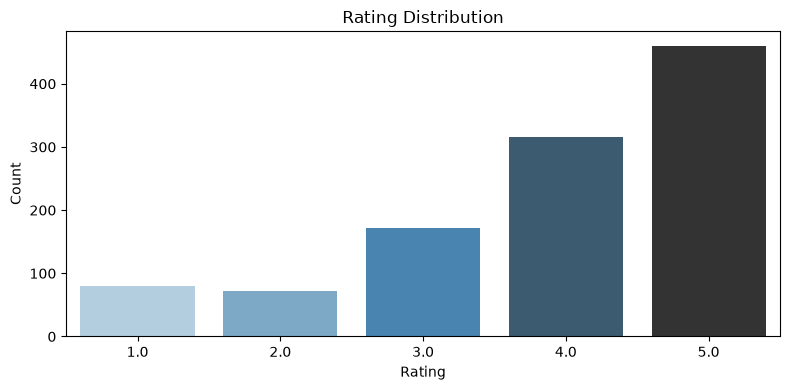

rating
1.0     80
2.0     72
3.0    172
4.0    316
5.0    460
Name: count, dtype: int64


In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="rating", hue="rating", palette="Blues_d", legend=False)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["rating"].value_counts().sort_index())

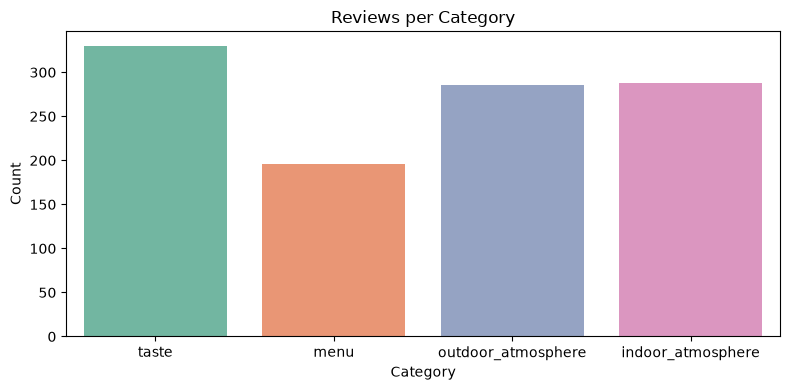

category_name
taste                 330
indoor_atmosphere     288
outdoor_atmosphere    286
menu                  196
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="category_name", hue="category_name", palette="Set2", legend=False)
plt.title("Reviews per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["category_name"].value_counts())

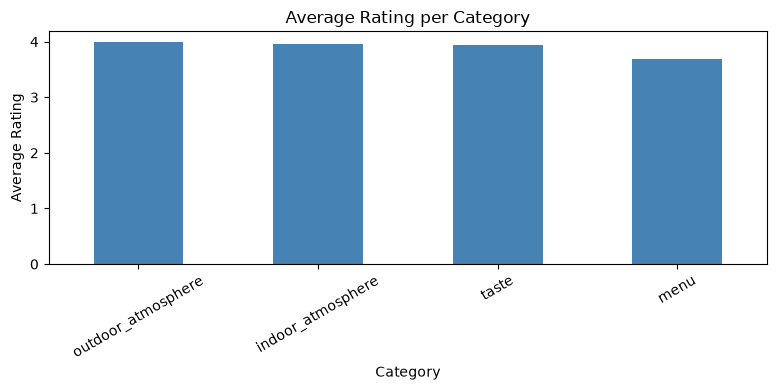

category_name
outdoor_atmosphere    3.99
indoor_atmosphere     3.96
taste                 3.94
menu                  3.69
Name: rating, dtype: float64


In [9]:
avg_rating = df.groupby("category_name")["rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
avg_rating.plot(kind="bar", color="steelblue")
plt.title("Average Rating per Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(avg_rating.round(2))

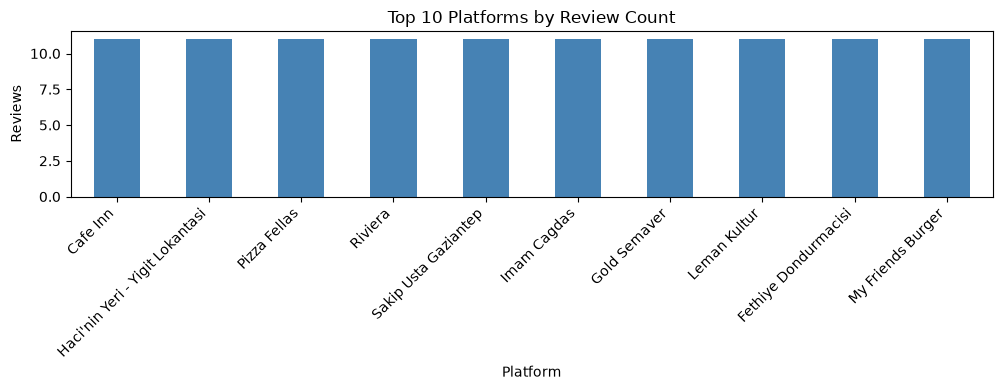

platform
Cafe Inn                           11
Haci'nin Yeri - Yigit Lokantasi    11
Pizza Fellas                       11
Riviera                            11
Sakip Usta Gaziantep               11
Imam Cagdas                        11
Gold Semaver                       11
Leman Kultur                       11
Fethiye Dondurmacisi               11
My Friends Burger                  11
Name: count, dtype: int64


In [10]:
top_platforms = df["platform"].value_counts().head(10)

plt.figure(figsize=(10, 4))
top_platforms.plot(kind="bar", color="steelblue")
plt.title("Top 10 Platforms by Review Count")
plt.xlabel("Platform")
plt.ylabel("Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(top_platforms)

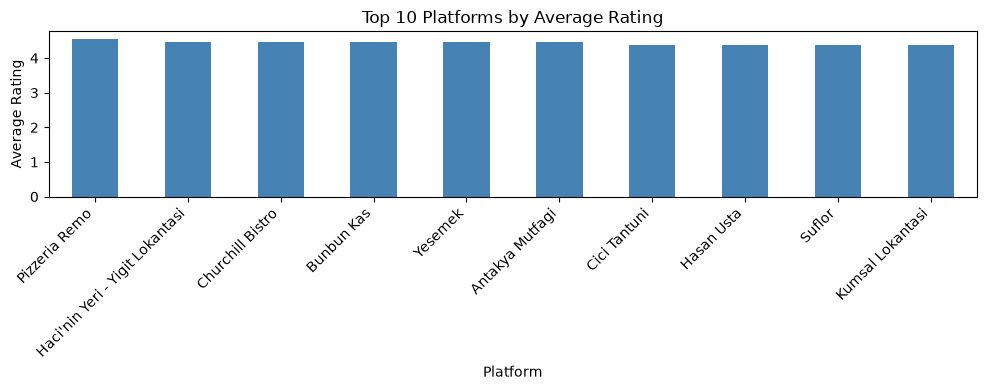

platform
Pizzeria Remo                      4.55
Haci'nin Yeri - Yigit Lokantasi    4.45
Churchill Bistro                   4.45
Bunbun Kas                         4.45
Yesemek                            4.45
Antakya Mutfagi                    4.45
Cici Tantuni                       4.36
Hasan Usta                         4.36
Suflor                             4.36
Kumsal Lokantasi                   4.36
Name: rating, dtype: float64


In [11]:
avg_by_platform = df.groupby("platform")["rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
avg_by_platform.plot(kind="bar", color="steelblue")
plt.title("Top 10 Platforms by Average Rating")
plt.xlabel("Platform")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(avg_by_platform.round(2))

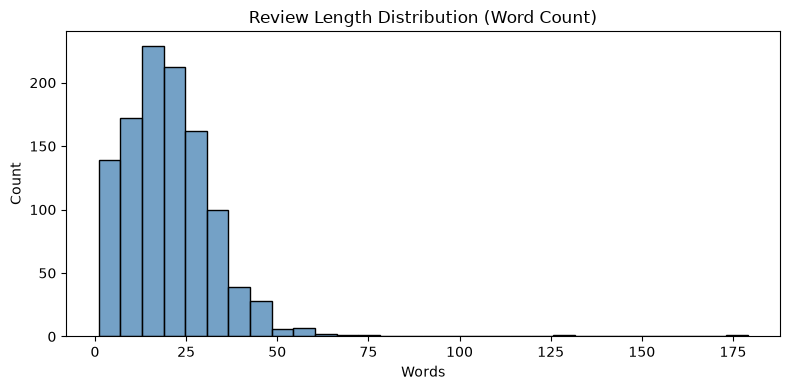

count    1100.00
mean       20.05
std        12.98
min         1.00
25%        11.00
50%        19.00
75%        27.00
max       179.00
Name: word_count, dtype: float64


In [12]:
# add a column with the number of words in each review
df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=30, color="steelblue")
plt.title("Review Length Distribution (Word Count)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["word_count"].describe().round(2))

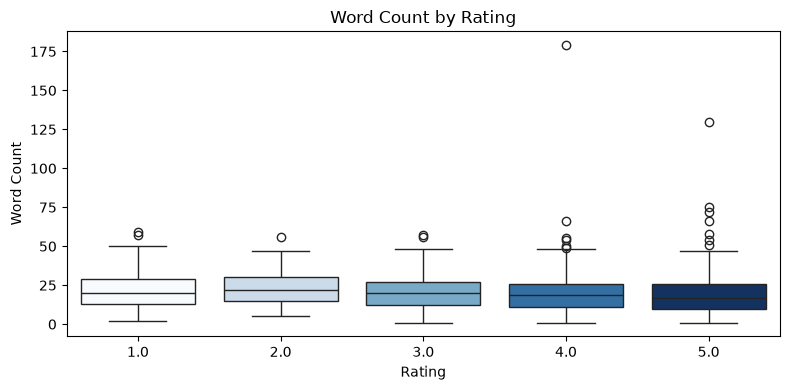

rating
1.0    21.76
2.0    23.36
3.0    20.14
4.0    20.12
5.0    19.16
Name: word_count, dtype: float64


In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="rating", y="word_count", hue="rating", palette="Blues", legend=False)
plt.title("Word Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Word Count")
plt.tight_layout()
plt.show()

print(df.groupby("rating")["word_count"].mean().round(2))